POPULATION (N = 10000)
 Population mean (mu) = 64.96
 Population SD (sigma) = 12.02
SAMPLE (n = 50)
 Sample mean (x-bar) = 65.70
 Sample SD (s) = 12.67
Sampling error (x-bar - mu) = 0.74

Means of 5 different random samples of size 50:
 Sample 5: mean = 64.74


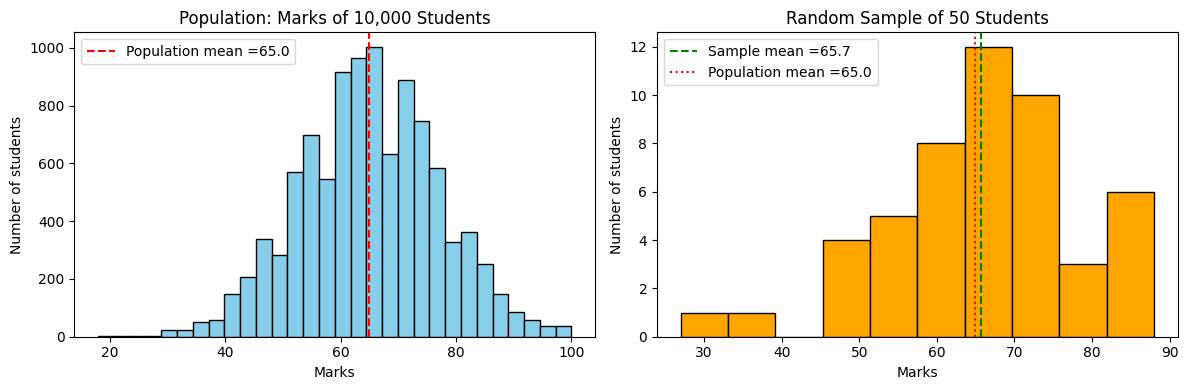

In [4]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42) # to get the same result every time
# Step 1: Create the population - marks of 10,000 students
population = np.random.normal(loc=65, scale=12, size=10000).round()
population = np.clip(population, 0, 100) # marks must be between 0 and 100
# Step 2: Draw a simple random sample of 50 students (without replacement)
sample = np.random.choice(population, size=50, replace=False)
# Step 3: Compare population parameters and sample statistics
print("POPULATION (N = 10000)")
print(f" Population mean (mu) = {population.mean():.2f}")
print(f" Population SD (sigma) = {population.std():.2f}")
print("SAMPLE (n = 50)")
print(f" Sample mean (x-bar) = {sample.mean():.2f}")
print(f" Sample SD (s) = {sample.std(ddof=1):.2f}")
print(f"Sampling error (x-bar - mu) = {sample.mean() - population.mean():.2f}")
# Step 4: Different random samples give different sample means
print("\nMeans of 5 different random samples of size 50:")
for i in range(1, 6):
  s = np.random.choice(population, size=50, replace=False)
print(f" Sample {i}: mean = {s.mean():.2f}")
# Step 5: Graph
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(population, bins=30, color='skyblue', edgecolor='black')
ax[0].axvline(population.mean(), color='red', linestyle='--', label=f'Population mean ={population.mean():.1f}')
ax[0].set_title('Population: Marks of 10,000 Students')
ax[0].set_xlabel('Marks'); ax[0].set_ylabel('Number of students'); ax[0].legend()
ax[1].hist(sample, bins=10, color='orange', edgecolor='black')

ax[1].axvline(sample.mean(), color='green', linestyle='--', label=f'Sample mean ={sample.mean():.1f}')
ax[1].axvline(population.mean(), color='red', linestyle=':', label=f'Population mean ={population.mean():.1f}')
ax[1].set_title('Random Sample of 50 Students')
ax[1].set_xlabel('Marks'); ax[1].set_ylabel('Number of students'); ax[1].legend()
plt.tight_layout()
plt.show()

Population mean = 40.04 min, Population SD = 7.99 min

    n   Mean of sample means    SE = σ/√n   SD of sample means
  100                  40.01         0.80                0.81


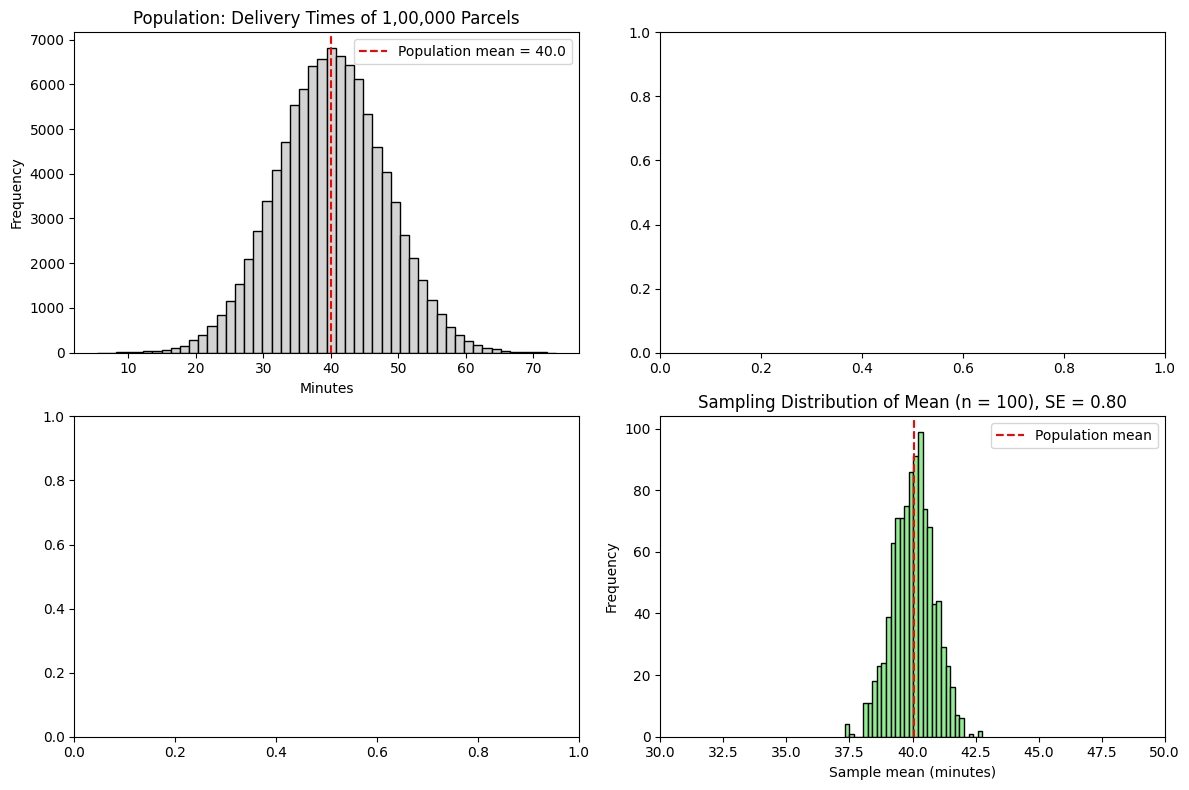


One sample of 30 parcels: mean = 39.50, estimated SE = s/√n= 1.28


In [8]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(1)
# Step 1: Population of delivery times (minutes)
population = np.random.normal(loc=40, scale=8, size=100000)
mu, sigma = population.mean(), population.std()
print(f"Population mean = {mu:.2f} min, Population SD = {sigma:.2f} min\n")
# Step 2: Take 1000 samples for each sample size and store their means
sample_sizes = [10, 30, 100]
num_samples = 1000
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.ravel()
ax[0].hist(population, bins=50, color='lightgray', edgecolor='black')
ax[0].axvline(mu, color='red', linestyle='--', label=f'Population mean = {mu:.1f}')
ax[0].set_title('Population: Delivery Times of 1,00,000 Parcels')
ax[0].set_xlabel('Minutes'); ax[0].set_ylabel('Frequency'); ax[0].legend()
print(f"{'n':>5} {'Mean of sample means':>22} {'SE = σ/√n':>12} {'SD of sample means':>20}")
for i, n in enumerate(sample_sizes):
  sample_means = [np.random.choice(population, size=n, replace=False).mean() for _ in range(num_samples)]
se_formula = sigma / np.sqrt(n)
se_observed = np.std(sample_means)
print(f"{n:>5} {np.mean(sample_means):>22.2f} {se_formula:>12.2f}{se_observed:>20.2f}")
ax[i+1].hist(sample_means, bins=30, color='lightgreen', edgecolor='black')
ax[i+1].axvline(mu, color='red', linestyle='--', label='Population mean')
ax[i+1].set_xlim(30, 50) # same scale so the spread can be compared
ax[i+1].set_title(f'Sampling Distribution of Mean (n = {n}), SE = {se_formula:.2f}')
ax[i+1].set_xlabel('Sample mean (minutes)'); ax[i+1].set_ylabel('Frequency');
ax[i+1].legend()
plt.tight_layout()
plt.show()
# Step 3: SE estimated from ONE sample of 30 parcels (sigma not known)
one_sample = np.random.choice(population, size=30, replace=False)
se_est = one_sample.std(ddof=1) / np.sqrt(30)
print(f"\nOne sample of 30 parcels: mean = {one_sample.mean():.2f}, estimated SE = s/√n= {se_est:.2f}")

Sample size (n) = 36
Sample mean (x-bar) = 496.67 g
Standard error = 1.3333
Z statistic = -2.5000
Critical value = ±1.96
p-value = 0.0124

Decision: |Z| > 1.96 -> Reject H0
Interpretation: The machine is NOT filling 500 g on average. It needs adjustment.


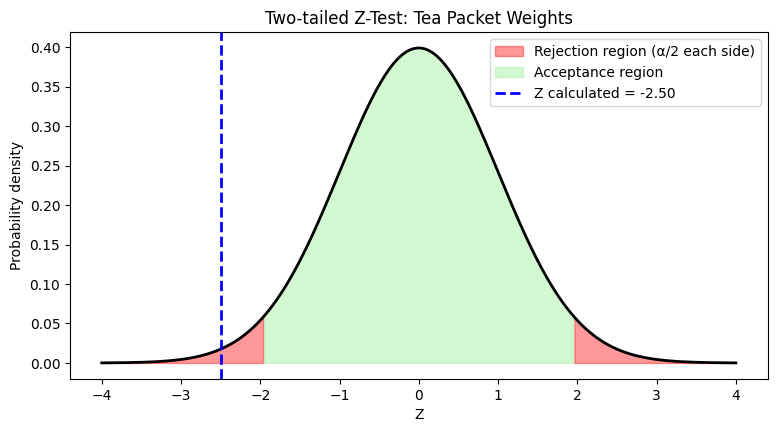

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# Step 1: Data - weights (g) of 36 packets
weights = np.array([495, 498, 492, 501, 497, 494, 499, 496, 503, 490, 497, 500,
493, 498, 495, 502, 491, 497, 499, 494, 496, 500, 492, 498,
497, 495, 501, 493, 496, 499, 494, 498, 502, 495, 497, 496])
mu0 = 500 # claimed mean
sigma = 8 # known population SD
alpha = 0.05
n = len(weights)
x_bar = weights.mean()
# Step 2: Z statistic
se = sigma / np.sqrt(n)
z = (x_bar - mu0) / se
# Step 3: Critical value and p-value (two-tailed)
z_critical = stats.norm.ppf(1 - alpha/2)
p_value = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"Sample size (n) = {n}")
print(f"Sample mean (x-bar) = {x_bar:.2f} g")
print(f"Standard error = {se:.4f}")
print(f"Z statistic = {z:.4f}")
print(f"Critical value = ±{z_critical:.2f}")
print(f"p-value = {p_value:.4f}")
# Step 4: Decision rule
if abs(z) > z_critical:
  print("\nDecision: |Z| > 1.96 -> Reject H0")
  print("Interpretation: The machine is NOT filling 500 g on average. It needs adjustment.")
else:
  print("\nDecision: |Z| <= 1.96 -> Fail to reject H0")
  print("Interpretation: The machine is filling 500 g on average.")
# Step 5: Graph - standard normal curve with rejection regions
x = np.linspace(-4, 4, 500)
y = stats.norm.pdf(x)
plt.figure(figsize=(9, 4.5))
plt.plot(x, y, 'k', lw=2)
plt.fill_between(x, y, where=(x <= -z_critical), color='red', alpha=0.4, label='Rejection region (α/2 each side)')
plt.fill_between(x, y, where=(x >= z_critical), color='red', alpha=0.4)
plt.fill_between(x, y, where=(abs(x) < z_critical), color='lightgreen', alpha=0.4,
label='Acceptance region')
plt.axvline(z, color='blue', linestyle='--', lw=2, label=f'Z calculated = {z:.2f}')
plt.title('Two-tailed Z-Test: Tea Packet Weights')
plt.xlabel('Z'); plt.ylabel('Probability density'); plt.legend()
plt.show()

Z calculated = 1.6666666666666667
Critical value = 1.959963984540054
P-value = 0.09558070454562939
Fail to reject H0
There is no significant difference in the mean IQ score.


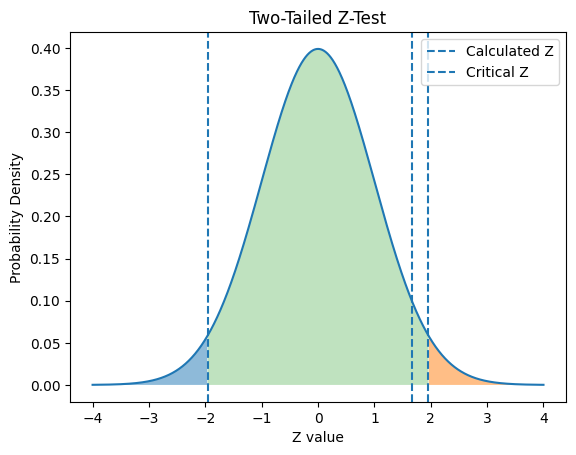

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

x_bar = 105
mu0 = 100
sigma = 15
n = 25
alpha = 0.05

z = (x_bar - mu0) / (sigma / np.sqrt(n))
print("Z calculated =", z)

q = 1 - alpha / 2
z_critical = stats.norm.ppf(q)
print("Critical value =", z_critical)

p_value = 2 * (1 - stats.norm.cdf(abs(z)))
print("P-value =", p_value)

print("Reject H0" if abs(z) > z_critical else "Fail to reject H0")
print("There is a significant difference in the mean IQ score." if abs(z) > z_critical else "There is no significant difference in the mean IQ score.")

x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

plt.plot(x, y)
plt.fill_between(x, y, where=(x <= -z_critical), alpha=0.5)
plt.fill_between(x, y, where=(x >= z_critical), alpha=0.5)
plt.fill_between(x, y, where=((x > -z_critical) & (x < z_critical)), alpha=0.3)

plt.axvline(z, linestyle='--', label='Calculated Z')
plt.axvline(-z_critical, linestyle='--', label='Critical Z')
plt.axvline(z_critical, linestyle='--')

plt.xlabel("Z value")
plt.ylabel("Probability Density")
plt.title("Two-Tailed Z-Test")
plt.legend()
plt.show()